In [1]:
import numpy as np 
import keras

# Fit model to data

## Preprocessing

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('../dataset/ghi_temp.csv')
df.head()

,Year,Month,Day,Hour,Minute,GHI,Temperature,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,2019,1,1,0,0,0,16.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,1,1,1,0,0,16.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,1,1,2,0,0,16.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,1,1,3,0,0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,1,1,4,0,0,15.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
ghi_col = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'GHI', 'Temperature']
df = df[ghi_col]
df.head()

,Year,Month,Day,Hour,Minute,GHI,Temperature
0,2019,1,1,0,0,0,16.3
1,2019,1,1,1,0,0,16.2
2,2019,1,1,2,0,0,16.1
3,2019,1,1,3,0,0,16.0
4,2019,1,1,4,0,0,15.9


In [5]:
df['datetime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])

In [6]:
df.head()

,Year,Month,Day,Hour,Minute,GHI,Temperature,datetime
0,2019,1,1,0,0,0,16.3,2019-01-01 00:00:00
1,2019,1,1,1,0,0,16.2,2019-01-01 01:00:00
2,2019,1,1,2,0,0,16.1,2019-01-01 02:00:00
3,2019,1,1,3,0,0,16.0,2019-01-01 03:00:00
4,2019,1,1,4,0,0,15.9,2019-01-01 04:00:00


In [7]:
df = df[['datetime', 'GHI', 'Temperature']]

df.set_index('datetime', inplace=True)

df.head()

,GHI,Temperature
datetime,,
2019-01-01 00:00:00,0,16.3
2019-01-01 01:00:00,0,16.2
2019-01-01 02:00:00,0,16.1
2019-01-01 03:00:00,0,16.0
2019-01-01 04:00:00,0,15.9


In [8]:
print(df.shape)

(8760, 2)


In [9]:
data_features = df[['GHI', 'Temperature']].values
data_target = df['Temperature'].values

In [10]:
look_back = 24 #menggunakan timestamp 24
n_ahead = 24 # predict 24 jam berikutnya

x_seq = []
y_seq = []

for i in range(len(data_features) - look_back - n_ahead + 1):
    print("i: ", i)
    print("untuk x seq: ", i + look_back)
    print("i + lookback: ", i + look_back)
    print("i + look_back + n_ahead: ", i + look_back + n_ahead)
    x_seq.append(data_features[i : (i + look_back)]) # mengambil value 24 jam sebelum
    y_seq.append(data_target[(i + look_back) : (i + look_back + n_ahead)]) #mengambil value 1 jam berikutnya

x_seq, y_seq = np.array(x_seq), np.array(y_seq)

i:  0
untuk x seq:  24
i + lookback:  24
i + look_back + n_ahead:  48
i:  1
untuk x seq:  25
i + lookback:  25
i + look_back + n_ahead:  49
i:  2
untuk x seq:  26
i + lookback:  26
i + look_back + n_ahead:  50
i:  3
untuk x seq:  27
i + lookback:  27
i + look_back + n_ahead:  51
i:  4
untuk x seq:  28
i + lookback:  28
i + look_back + n_ahead:  52
i:  5
untuk x seq:  29
i + lookback:  29
i + look_back + n_ahead:  53
i:  6
untuk x seq:  30
i + lookback:  30
i + look_back + n_ahead:  54
i:  7
untuk x seq:  31
i + lookback:  31
i + look_back + n_ahead:  55
i:  8
untuk x seq:  32
i + lookback:  32
i + look_back + n_ahead:  56
i:  9
untuk x seq:  33
i + lookback:  33
i + look_back + n_ahead:  57
i:  10
untuk x seq:  34
i + lookback:  34
i + look_back + n_ahead:  58
i:  11
untuk x seq:  35
i + lookback:  35
i + look_back + n_ahead:  59
i:  12
untuk x seq:  36
i + lookback:  36
i + look_back + n_ahead:  60
i:  13
untuk x seq:  37
i + lookback:  37
i + look_back + n_ahead:  61
i:  14
untuk x s

In [11]:
print(x_seq.shape)
print(y_seq.shape)

(8713, 24, 2)
(8713, 24)


In [12]:
split_point = int(len(x_seq) * 0.8) # 80% for training and 20% for testing

x_train, x_test = x_seq[:split_point], x_seq[split_point:]
y_train, y_test = y_seq[:split_point], y_seq[split_point:]

#flatten the y

y_train = y_train.flatten()
y_test = y_test.flatten()

print(f'x_train shape: {x_train.shape}, x_test shape: {x_test.shape}')
print(f'y_train shape: {y_train.shape}, y_test shape: {y_test.shape}')

x_train shape: (6970, 24, 2), x_test shape: (1743, 24, 2)
y_train shape: (167280,), y_test shape: (41832,)


In [13]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler_x = RobustScaler()
scaler_y = RobustScaler()

#fit dan transform the training data
#kalau mau fit transform, data harus 2 dimensi. untuk x, kembalikan ke 3 dimensi. untuk y, kembalikan 1 dimensi
x_train_scaled = scaler_x.fit_transform(x_train.reshape(-1, 2)).reshape(x_train.shape[0], x_train.shape[1], 2) 
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, n_ahead)).reshape(-1, n_ahead, 1)
# y_train_scaled = y_train_scaled.flatten()

# tranform the testing data
x_test_scaled = scaler_x.fit_transform(x_test.reshape(-1, 2)).reshape(x_test.shape[0], x_test.shape[1], 2)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, n_ahead)).reshape(-1, n_ahead, 1)
# y_test_scaled = y_test_scaled.flatten()

# # Reshape X_train and X_test to 3D for LSTM input (samples, time steps, features)
# X_train_scaled = X_train.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
# X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Check the shapes after standardization
print(f'X_train_scaled shape: {x_train_scaled.shape}, X_test_scaled shape: {x_test_scaled.shape}')
print(f'y_train_scaled shape: {y_train_scaled.shape}, y_test_scaled shape: {y_test_scaled.shape}')

X_train_scaled shape: (6970, 24, 2), X_test_scaled shape: (1743, 24, 2)
y_train_scaled shape: (6970, 24, 1), y_test_scaled shape: (1743, 24, 1)


# Hyper parameters dan model configuration

In [14]:
keras.backend.clear_session()

#hidden neuron in each layer dari encoder dan decoder

layers = [35, 35]

learning_rate = 0.01
decay = 0 #learning rate decay

# optimizer "sgd" (stochastic gradient descent)
optimizer = keras.optimizers.Adam(learning_rate=learning_rate, decay=decay)

num_input_features = 2 #dimensi input pada tiap time step. kita pake 2 feature
num_output_features = 1 #dimensi output pada tiap timestep

loss = "mse"

lambda_regulariser = 0.000001 #ga digunakan kalau regulariser none
regulariser = None #possible regulariser: keras.regularizers.l2 (lambda_regularizer)

batch_size = 512
steps_per_epoch = 200 #batch size * step per epoch = total number dari training examples
epochs = 15

input_sequence_length = 24 #length sequence yang digunakan encoder. disiini 24 jam
target_sequence_length = 1 #length dari sequence predicted decoder. disini predict 1 jam berikutnya
num_steps_to_predict = 24  #length yang digunakan ketika testing model. disini pake predict 1 jam



/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


# Create model

## Create encoder

In [15]:
# Define an input sequence.
encoder_inputs = keras.layers.Input(shape=(None, num_input_features))

#membuat list RNN cells, digabung menjadi single layer

encoder_cells = []
for hidden_neurons in layers:
    encoder_cells.append(keras.layers.GRUCell(hidden_neurons,
                                              kernel_regularizer=regulariser,
                                              recurrent_regularizer=regulariser,
                                              bias_regularizer=regulariser))

encoder = keras.layers.RNN(encoder_cells, return_state=True)

encoder_outputs_and_states = encoder(encoder_inputs)

# Discard encoder outputs and only keep the states.
# The outputs are of no interest to us, the encoder's
# job is to create a state describing the input sequence.
encoder_states = encoder_outputs_and_states[1:]

## Create Decoder

In [16]:
# The decoder input will be set to zero (see random_sine function of the utils module).
# Do not worry about the input size being 1, I will explain that in the next cell.
decoder_inputs = keras.layers.Input(shape=(None, 1))

decoder_cells = []
for hidden_neurons in layers:
    decoder_cells.append(keras.layers.GRUCell(hidden_neurons,
                                              kernel_regularizer=regulariser,
                                              recurrent_regularizer=regulariser,
                                              bias_regularizer=regulariser))

decoder = keras.layers.RNN(decoder_cells, return_sequences=True, return_state=True)

# Set the initial state of the decoder to be the ouput state of the encoder.
# This is the fundamental part of the encoder-decoder.
decoder_outputs_and_states = decoder(decoder_inputs, initial_state=encoder_states)

# Only select the output of the decoder (not the states)
decoder_outputs = decoder_outputs_and_states[0]

# Apply a dense layer with linear activation to set output to correct dimension
# and scale (tanh is default activation for GRU in Keras, our output sine function can be larger then 1)
decoder_dense = keras.layers.Dense(num_output_features,
                                   activation='linear',
                                   kernel_regularizer=regulariser,
                                   bias_regularizer=regulariser)

decoder_outputs = decoder_dense(decoder_outputs)

## Create model and compile

Train model punya 2 input: encoder_inputs dan decoder_inputs

encoder_inputs = input series
decoder_inputs = di set 0 awalnya

In [17]:
# Create a model using the functional API provided by Keras.
# The functional API is great, it gives an amazing amount of freedom in architecture of your NN.
# A read worth your time: https://keras.io/getting-started/functional-api-guide/ 
model = keras.models.Model(inputs=[encoder_inputs, decoder_inputs], outputs=decoder_outputs)
model.compile(optimizer=optimizer, loss=loss)

## Fit model to data

In [18]:
from util import fitModel, plot_prediction

In [19]:
train_data_generator = fitModel(batch_size, steps_per_epoch, 
                                x_train_scaled, y_train_scaled)

model.fit(train_data_generator, steps_per_epoch=steps_per_epoch, epochs=epochs)

Epoch 1/15


/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_4']. Received: the structure of inputs=('*', '*')
  warnings.warn(


200/200 ━━━━━━━━━━━━━━━━━━━━ 92s 433ms/step - loss: 0.0862
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 84s 419ms/step - loss: 0.0203
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 84s 420ms/step - loss: 0.0166
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 85s 427ms/step - loss: 0.0117
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 84s 420ms/step - loss: 0.0077
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 88s 438ms/step - loss: 0.0053
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 86s 432ms/step - loss: 0.0041
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 67s 332ms/step - loss: 0.0035
Epoch 9/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 229ms/step - loss: 0.0030
Epoch 10/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 236ms/step - loss: 0.0026
Epoch 11/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 229ms/step - loss: 0.0023
Epoch 12/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 234ms/step - loss: 0.0021
Epoch 13/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 228ms/step - loss: 0.0020
Epoch 14/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 231ms/step - loss: 0.0018
Epoch 15/15
200/200 ━━━━━━

# Create Prediction Models

In [20]:
encoder_predict_model = keras.models.Model(encoder_inputs,
                                           encoder_states)

decoder_states_inputs = []

# Read layers backwards to fit the format of initial_state
# For some reason, the states of the model are order backwards (state of the first layer at the end of the list)
# If instead of a GRU you were using an LSTM Cell, you would have to append two Input tensors since the LSTM has 2 states.
for hidden_neurons in layers[::-1]:
    # One state for GRU
    decoder_states_inputs.append(keras.layers.Input(shape=(hidden_neurons,)))

decoder_outputs_and_states = decoder(
    decoder_inputs, initial_state=decoder_states_inputs)

decoder_outputs = decoder_outputs_and_states[0]
decoder_states = decoder_outputs_and_states[1:]

decoder_outputs = decoder_dense(decoder_outputs)

# decoder_predict_model = keras.models.Model(
#         [decoder_inputs] + decoder_states_inputs,
#         [decoder_outputs] + decoder_states)

decoder_predict_model = keras.models.Model(
    inputs=[decoder_inputs] + decoder_states_inputs,
    outputs=[decoder_outputs] + [state for state in decoder_outputs_and_states[1:]]
)

In [21]:
# Let's define a small function that predicts based on the trained encoder and decoder models

def predict(x, encoder_predict_model, decoder_predict_model, num_steps_to_predict):
    """Predict time series with encoder-decoder.
    
    Uses the encoder and decoder models previously trained to predict the next
    num_steps_to_predict values of the time series.
    
    Arguments
    ---------
    x: input time series of shape (batch_size, input_sequence_length, input_dimension).
    encoder_predict_model: The Keras encoder model.
    decoder_predict_model: The Keras decoder model.
    num_steps_to_predict: The number of steps in the future to predict
    
    Returns
    -------
    y_predicted: output time series for shape (batch_size, target_sequence_length,
        ouput_dimension)
    """
    y_predicted = []

    # Encode the values as a state vector
    states = encoder_predict_model.predict(x)

    # The states must be a list
    if not isinstance(states, list):
        states = [states]

    # Generate first value of the decoder input sequence
    decoder_input = np.zeros((x.shape[0], 1, 1))


    for _ in range(num_steps_to_predict):
        outputs_and_states = decoder_predict_model.predict(
        [decoder_input] + states, batch_size=batch_size)
        output = outputs_and_states[0]
        states = outputs_and_states[1:]

        # add predicted value
        y_predicted.append(output)

    return np.concatenate(y_predicted, axis=1)
    

In [22]:
test_data_generator = fitModel(batch_size, steps_per_epoch, 
                                x_test_scaled, y_test_scaled)

(x_test_scaled2, _), y_test_scaled2 = next(test_data_generator)

In [23]:
print(x_test_scaled2.shape)
print(y_test_scaled2.shape)

(1743, 24, 2)
(1743, 24, 1)


In [24]:
y_test_predicted = predict(x_test_scaled2, encoder_predict_model, decoder_predict_model, num_steps_to_predict)

print(y_test_predicted.shape)
    

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_4', 'keras_tensor_9', 'keras_tensor_10']. Received: the structure of inputs=('*', ('*', '*'))
  warnings.warn(


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/stepWARNING:tensorflow:6 out of the last 63 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x32f517240> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_4', 'keras_tensor_9', 'keras_tensor_10']. Received: the structure of inputs=('*', '*', '*')
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
(1743, 24, 1)


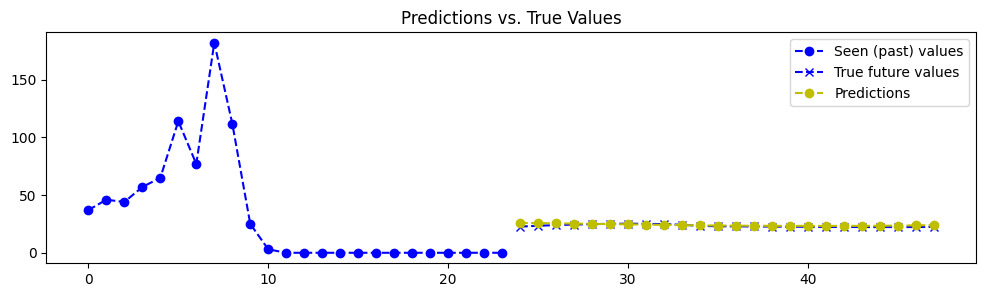

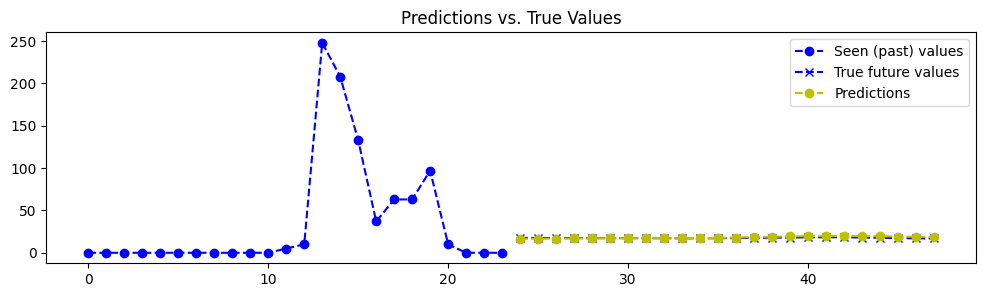

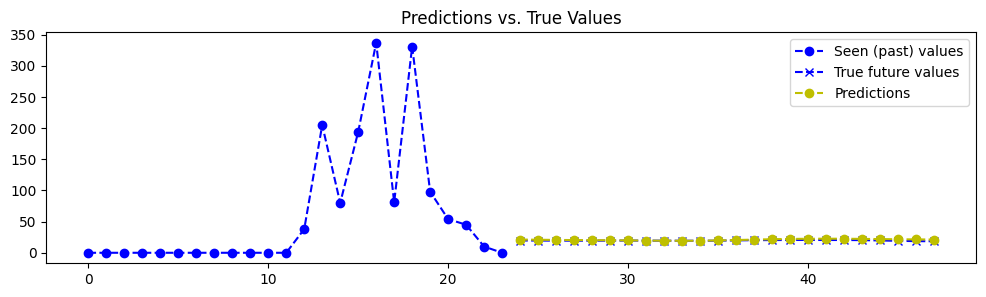

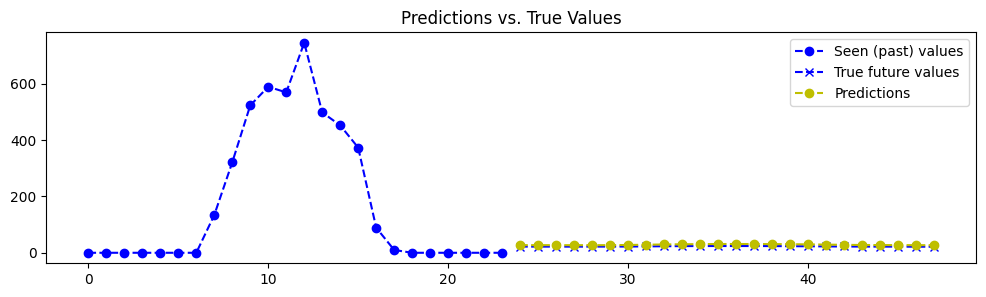

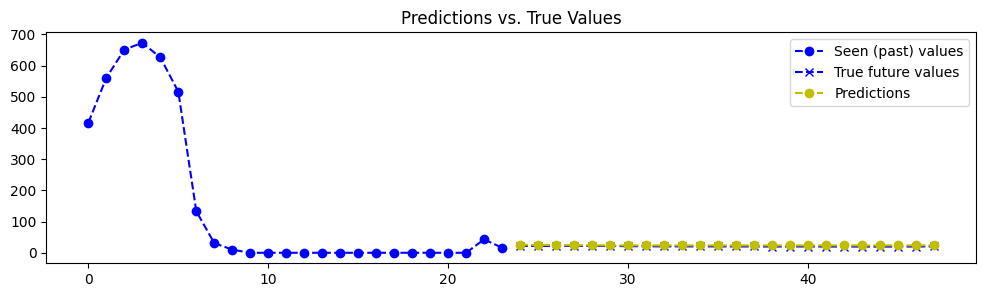

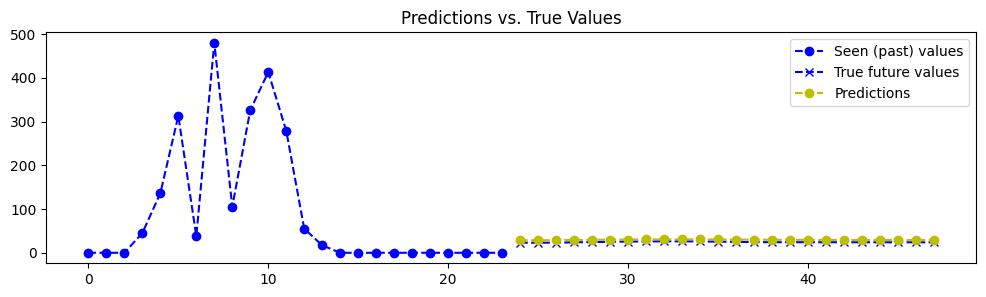

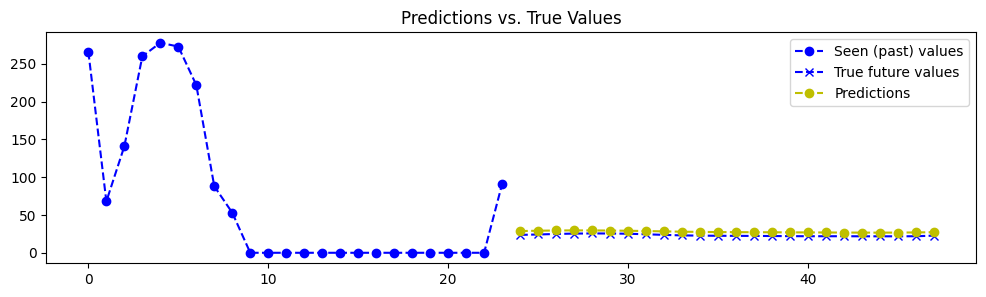

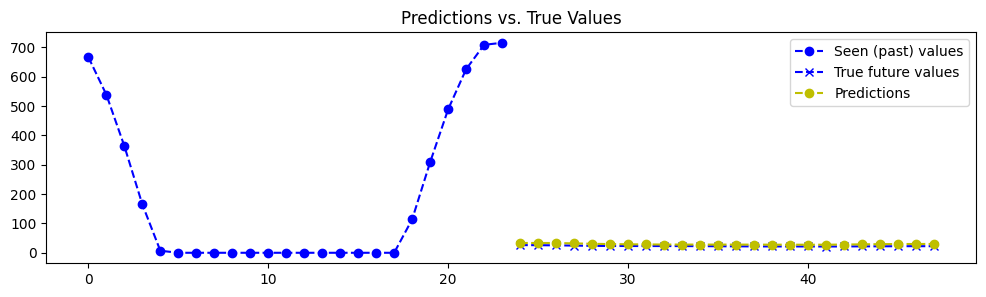

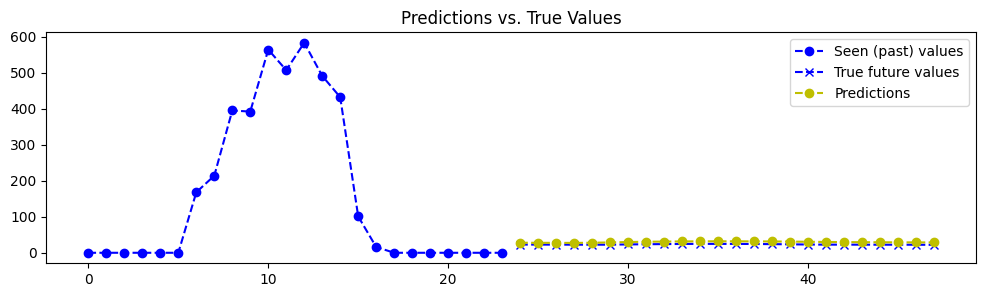

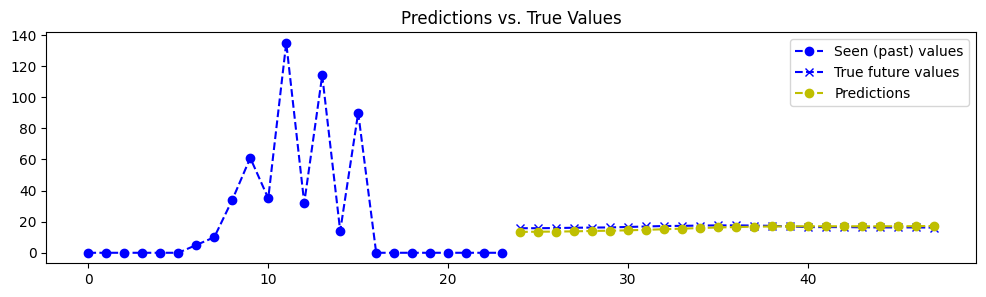

In [25]:
x_test_nonScaled = scaler_x.inverse_transform(x_test_scaled2.reshape(-1, 2)).reshape(x_test_scaled2.shape[0], x_test_scaled2.shape[1], 2)
y_test_nonScaled = scaler_y.inverse_transform(y_test_scaled2.reshape(-1, n_ahead)).reshape(-1, n_ahead, 1)
y_test_predict_nonScaled = scaler_y.inverse_transform(y_test_predicted.reshape(-1, n_ahead)).reshape(-1, n_ahead, 1)

# Select 10 random examples to plot
indices = np.random.choice(range(x_test.shape[0]), replace=False, size=10)


for index in indices:
    plot_prediction(x_test_nonScaled[index, :, :], y_test_nonScaled[index, :, :], y_test_predict_nonScaled[index, :, :])